In [7]:
import glob
import re
import os

first_layer_names = glob.glob('[0-9][0-9][0-9]',root_dir='./mached_catalog')
print(len(first_layer_names))
count = 0
print(os.getcwd())
for name in first_layer_names:
    second_layer_names = glob.glob('[0-9][0-9][0-9][0-9]*',                                   root_dir='./mached_catalog/'+name)
        
    for long_name in second_layer_names:
        if True == os.path.isfile('./mached_catalog/'+name+'/'+long_name+'/'+long_name+'_w2_mached.csv'):
            count += 1
print(count)

359
/home/kangzihan/project_unTimely_light_curve
18221


In [2]:
import numpy as np

def calculate_magnitude(flux):
    if flux <= 0:
        return np.nan
    return 22.5 - 2.5 * np.log10(flux)

def calculate_error(flux,dflux):
    mag_upper = calculate_magnitude(flux - dflux)
    mag_lower = calculate_magnitude(flux + dflux)
    dmag = (mag_upper - mag_lower) / 2
    return dmag

cal_mag_ufunc  = np.frompyfunc(calculate_magnitude,1,1)
cal_error_ufunc  = np.frompyfunc(calculate_error,2,1)



In [3]:

def make_single_light_curve(table, index):
    line = table.iloc[index]
    line_len = len(line)
    ra = line[0]
    dec = line[1]
    flux_unfiltered = line[3:line_len:3]
    flux = np.array(flux_unfiltered[flux_unfiltered.notnull()])
    dflux_unfiltered = line[4:line_len:3]
    dflux = np.array(dflux_unfiltered[dflux_unfiltered.notnull()])
    mjdmean_unfiltered = line[5:line_len:3]
    mjdmean = np.array(mjdmean_unfiltered[mjdmean_unfiltered.notnull()])
    assert len(flux)==len(dflux) and len(dflux)==len(mjdmean), 'light curve uncomplete!'
    mag = cal_mag_ufunc(flux)
    error = cal_error_ufunc(flux,dflux)
    return ra,dec,mag, error, mjdmean


In [ ]:
[2609.0, 3470.0, 4297.0, 4355.0, 5495.0, 6734.0, 6901.0, 7040.0, 8165.0, 8529.0, 8669.0, 9614.0, 10703.0, 12966.0, 13094.0, 15923.0, 16396.0, 16424.0, 17005.0, 17276.0, 18247.0, 19667.0, 20653.0, 20812.0, 21101.0, 21238.0, 21279.0, 22203.0, 23388.0, 24230.0, 24458.0, 26393.0, 26573.0, 28299.0, 28781.0, 28784.0, 29084.0, 30295.0, 30847.0, 31115.0, 32417.0]


/home/kangzihan/project_unTimely_light_curve
348.0819243 , 72.6908045 ; 348.0819243 , 72.6908045


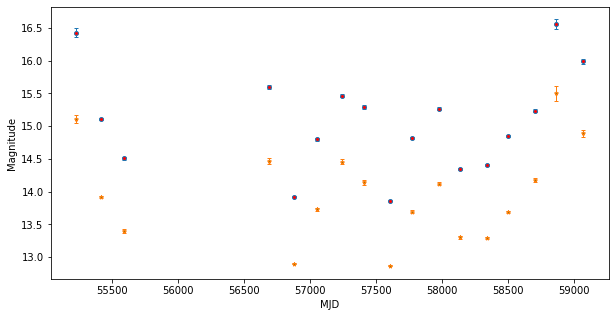

In [16]:
import os
import pandas as pd
print(os.getcwd())
name = '350'
long_name = '3502p726'
# table = pd.read_csv('./mached_catalog/116/1165p287/1165p287_w1_mached.csv')
table1 = pd.read_csv('./mached_catalog/'+name+'/'+long_name+'/'+long_name+'_w1_mached.csv')
table2 = pd.read_csv('./mached_catalog/'+name+'/'+long_name+'/'+long_name+'_w2_mached.csv')

import matplotlib.pyplot as plt
id_w1 = 3273
id_w2 = 3268
ra1,dec1,mag1,error1,mjdmean1 = make_single_light_curve(table1,int(id_w1-1))
ra2,dec2,mag2,error2,mjdmean2 = make_single_light_curve(table2,int(id_w2-1))
print(ra1,',',dec1,';',ra2,',',dec2)
plt.figure(figsize=(10,5))


plt.xlabel('MJD')
plt.ylabel('Magnitude')
plt.errorbar(mjdmean1,mag1,error1,fmt='o',ms=4, mfc='r', elinewidth=1, capsize=2)

plt.errorbar(mjdmean2,mag2,error2,fmt='*',ms=4, mfc='g', elinewidth=1, capsize=2)
plt.show()


In [4]:
target_list = pd.read_csv('../catalogues/8.0-18.1_w1_co_above_0.6_var_table_new.csv')


353.1412018 , 56.133391 353.1412018 56.133391


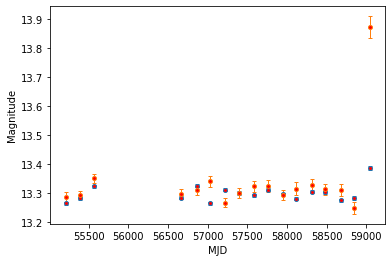

In [7]:
import os
import pandas as pd
from IPython.display import clear_output
import matplotlib.pyplot as plt


# target_list = pd.read_csv('../catalogues/stand_pho_var.csv')


i = 3000000


while i < len(target_list):
    clear_output(wait=True)
    # ra,dec = target_list.iloc[i]['ra'],target_list.iloc[i]['dec']
    # print(ra,dec)
    long_name = target_list.iloc[i]['long_name']
    id_in_matched = target_list.iloc[i]['id_in_matched']
    # target_id = target_list.iloc[i]['TARGETID']
    id_w1 = target_list.iloc[i]['id_w1']
    id_w2 = target_list.iloc[i]['id_w2']
    name = long_name[0:3]
    table1 = pd.read_csv('./mached_catalog/'+name+'/'+long_name+'/'+long_name+'_w1_mached.csv')
    table2 = pd.read_csv('./mached_catalog/'+name+'/'+long_name+'/'+long_name+'_w2_mached.csv')
    ra1,dec1,mag1,error1,mjdmean1 = make_single_light_curve(table1,int(id_w1-1))
    ra2,dec2,mag2,error2,mjdmean2 = make_single_light_curve(table2,int(id_w2-1))
    # df1 = pd.DataFrame({'mag':mag1,'error':error1,'mjdmean':mjdmean1})
    # df2 = pd.DataFrame({'mag':mag2,'error':error2,'mjdmean':mjdmean2})
    # df1.to_csv('./tmp_data/w1/'+str(target_id)+'_'+str(ra)+'_'+str(dec)+'.csv',index=False)
    # df2.to_csv('./tmp_data/w2/'+str(target_id)+'_'+str(ra)+'_'+str(dec)+'.csv',index=False)
    i += np.random.randint(1,50)
    # i+=1
    print(ra1,',',dec1,ra2,dec2)
    plt.xlabel('MJD')
    plt.ylabel('Magnitude')
    plt.errorbar(mjdmean1,mag1,error1,fmt='o',ms=4, mfc='r', elinewidth=1, capsize=2)
    plt.errorbar(mjdmean2,mag2,error2,fmt='o',ms=4, mfc='r', elinewidth=1, capsize=2)
    plt.show()
    user_input = input('Do you want to continue? (y/n)')
    if user_input == 'n':
        break

269.3639558 , -38.5949567 作为一个重要的对比例子
282.5969059 , -8.4970424 +1

In [ ]:
import os
import pandas as pd
print(os.getcwd())
name = '347'
long_name = '3476m122'
# table = pd.read_csv('./mached_catalog/116/1165p287/1165p287_w1_mached.csv')
table1 = pd.read_csv('./mached_catalog/'+name+'/'+long_name+'/'+long_name+'_w1_mached.csv')
table2 = pd.read_csv('./mached_catalog/'+name+'/'+long_name+'/'+long_name+'_w2_mached.csv')

import matplotlib.pyplot as plt
id_w1 = 9892
id_w2 = 9517
ra1,dec1,mag1,error1,mjdmean1 = make_single_light_curve(table1,int(id_w1-1))
ra2,dec2,mag2,error2,mjdmean2 = make_single_light_curve(table2,int(id_w2-1))
print(ra1,',',dec1,';',ra2,',',dec2)
plt.figure(figsize=(10,5))


plt.xlabel('MJD')
plt.ylabel('Magnitude')
plt.errorbar(mjdmean1,mag1,error1,fmt='o',ms=4, mfc='r', elinewidth=1, capsize=2)

plt.errorbar(mjdmean2,mag2,error2,fmt='*',ms=4, mfc='g', elinewidth=1, capsize=2)
plt.show()

In [ ]:
len(mag1)

In [ ]:
count = 0
light_count = 0
for i in range(0,len(table)):
    flux,dflux,mjdmean = make_single_light_curve(table,i)
    if len(flux) >= 10:
        count += 1
    mean_flux = np.mean(flux)
    if mean_flux > 500:
        light_count += 1
print(count)
print(light_count)

In [ ]:
# def generage_name(ra,dec):
#     name = str(int(ra))[0:3]
#     if len(name) == 1:
#         name = '00' + name
#     elif len(name) == 2:
#         name = '0' + name
    
#     long_name_prefix = name + str(ra-int(ra))[2]
#     long_name_mid = 'm' if dec < 0 else 'p'

#     long_name_suffix = str(abs(int(dec)))[0:3]

#     if len(long_name_suffix) == 1:
#         long_name_suffix = '00' + long_name_suffix
#     elif len(long_name_suffix) == 2:
#         long_name_suffix = '0' + long_name_suffix

#     long_name = long_name_prefix + long_name_mid + long_name_suffix

#     return name, long_name

# 这是错误逻辑

In [ ]:
# import pandas as pd
# import numpy as np

# ra,dec,index = 21.23937,10.05593,32.0
# index = int(index)

# name, long_name = generage_name(ra,dec)
# table = pd.read_csv(table = pd.read_csv('./mached_catalog/%s/%s/%s_w1_mached.csv'%(name,long_name,long_name)))
# ra_in_table = table['ra'][index]
# dec_in_table = table['dec'][index]

# print(ra_in_table,dec_in_table)
# import matplotlib.pyplot as plt
# ra,dec,mag,error,mjdmean = make_single_light_curve(table,index)
# print(ra,',',dec)
# plt.errorbar(mjdmean,mag,error,fmt='o',ms=4, mfc='r', elinewidth=1, capsize=2)